<a href="https://colab.research.google.com/github/hamidkhj/Tabular-Transformer/blob/main/FT_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# mambular

In [ ]:
!pip install mambular --quiet

In [ ]:
!pip install -U torchvision lightning --quiet

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd


# load data
data = pd.read_excel('/content/Gene_data.xlsx')
data = data.iloc[:, 2:]


In [ ]:
data.head()

,"Overall Survival (Months, Target Variable)",AATF,ABCB1,ABCC1,AIFM2,APAF1,ARID3A,AR,ATF3,ATM,...,TNFRSF10B,TP53AIP1,TP53I13,TP53INP1,TP53,VEGFA,VRK1,WWP1,XAF1,ZMAT3
0,0,0.9988,-1.5231,-0.4906,-0.7447,0.1029,1.9877,-0.7707,1.2889,-1.8634,...,0.3761,0.4918,-0.1941,1.6935,0.1387,2.1493,0.0142,0.4614,-0.0144,0.2518
1,50.03,0.3755,-0.8708,0.4529,-0.8756,1.2589,0.5747,-0.3418,-0.8055,0.5096,...,-0.3198,0.1544,-0.1856,0.8538,1.1496,-0.3610,-0.6601,-0.0750,0.1515,0.8868
2,3.98,1.8270,0.6595,-0.7784,-0.5137,0.0004,-0.4945,-0.4633,1.9392,-0.7617,...,1.9002,-1.2875,0.5143,-1.7186,-2.1822,1.0916,0.6690,-0.4999,0.2617,-0.1294
3,19.94,0.3980,-0.7060,0.2884,0.2070,0.9118,0.5153,-0.0890,0.4252,-0.0280,...,0.2665,-0.6153,0.6822,0.0903,0.1246,1.3032,-1.8678,-1.8233,0.1334,0.4065
4,13.99,-0.8594,0.3491,0.5760,0.8067,-0.0444,-0.1026,0.5716,0.3567,0.2929,...,0.6528,-0.2299,-1.0036,-0.1459,0.7752,-0.3026,-0.7277,0.4800,-0.6624,0.8609


In [ ]:
data = data[data['Overall Survival (Months, Target Variable)'] != '[Not Available]']

In [ ]:
X = data.iloc[:, 1:]  # Features (all columns except the target)
y = data.iloc[:, 0]   # Target (first column after dropping IDs)

In [ ]:
# Standard normalize features and target
y = StandardScaler().fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test-validation split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
from mambular.models import FTTransformerRegressor
import torch.nn as nn

model = FTTransformerRegressor(
    numerical_preprocessing="ple",
    n_bins=64,
    d_model=64,
)
model.fit(X_train, y_train, X_val=X_val, y_val=y_val, max_epochs=200, lr=1e-03)

model.evaluate(X_test, y_test)

Numerical Feature: AATF, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Numerical Feature: ABCB1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Numerical Feature: ABCC1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Numerical Feature: AIFM2, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Numerical Feature: APAF1, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Numerical Feature: ARID3A, Info: {'preprocessing': 'imputer -> minmax -> ple', 'dimension': 64, 'categories': None}
--------------------------------------------------
Nume

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
INFO: Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:lightning.pytorch.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.py

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

{'Mean Squared Error': 0.4782494914751436}

# revisit models

In [ ]:
import math
import typing as ty

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from torch import Tensor

class Tokenizer(nn.Module):
    category_offsets: ty.Optional[Tensor]

    def __init__(
        self,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        d_token: int,
        bias: bool,
    ) -> None:
        super().__init__()
        if categories is None:
            d_bias = d_numerical
            self.category_offsets = None
            self.category_embeddings = None
        else:
            d_bias = d_numerical + len(categories)
            category_offsets = torch.tensor([0] + categories[:-1]).cumsum(0)
            self.register_buffer('category_offsets', category_offsets)
            self.category_embeddings = nn.Embedding(sum(categories), d_token)
            nn_init.kaiming_uniform_(self.category_embeddings.weight, a=math.sqrt(5))

        self.weight = nn.Parameter(Tensor(d_numerical + 1, d_token))
        self.bias = nn.Parameter(Tensor(d_bias, d_token)) if bias else None
        nn_init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            nn_init.kaiming_uniform_(self.bias, a=math.sqrt(5))

    @property
    def n_tokens(self) -> int:
        return len(self.weight) + (
            0 if self.category_offsets is None else len(self.category_offsets)
        )

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x_some = x_num if x_cat is None else x_cat
        assert x_some is not None
        x_num = torch.cat(
            [torch.ones(len(x_some), 1, device=x_some.device)]
            + ([] if x_num is None else [x_num]),
            dim=1,
        )
        x = self.weight[None] * x_num[:, :, None]
        if x_cat is not None:
            x = torch.cat(
                [x, self.category_embeddings(x_cat + self.category_offsets[None])],
                dim=1,
            )
        if self.bias is not None:
            bias = torch.cat(
                [
                    torch.zeros(1, self.bias.shape[1], device=x.device),
                    self.bias,
                ]
            )
            x = x + bias[None]
        return x

class MultiheadAttention(nn.Module):
    def __init__(
        self, d: int, n_heads: int, dropout: float, initialization: str
    ) -> None:
        if n_heads > 1:
            assert d % n_heads == 0
        assert initialization in ['xavier', 'kaiming']

        super().__init__()
        self.W_q = nn.Linear(d, d)
        self.W_k = nn.Linear(d, d)
        self.W_v = nn.Linear(d, d)
        self.W_out = nn.Linear(d, d) if n_heads > 1 else None
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout) if dropout else None

        for m in [self.W_q, self.W_k, self.W_v]:
            if initialization == 'xavier' and (n_heads > 1 or m is not self.W_v):
                nn_init.xavier_uniform_(m.weight, gain=1 / math.sqrt(2))
            nn_init.zeros_(m.bias)
        if self.W_out is not None:
            nn_init.zeros_(self.W_out.bias)

    def _reshape(self, x: Tensor) -> Tensor:
        batch_size, n_tokens, d = x.shape
        d_head = d // self.n_heads
        return (
            x.reshape(batch_size, n_tokens, self.n_heads, d_head)
            .transpose(1, 2)
            .reshape(batch_size * self.n_heads, n_tokens, d_head)
        )

    def forward(
        self,
        x_q: Tensor,
        x_kv: Tensor,
        key_compression: ty.Optional[nn.Linear],
        value_compression: ty.Optional[nn.Linear],
    ) -> Tensor:
        q, k, v = self.W_q(x_q), self.W_k(x_kv), self.W_v(x_kv)
        for tensor in [q, k, v]:
            assert tensor.shape[-1] % self.n_heads == 0
        if key_compression is not None:
            assert value_compression is not None
            k = key_compression(k.transpose(1, 2)).transpose(1, 2)
            v = value_compression(v.transpose(1, 2)).transpose(1, 2)
        else:
            assert value_compression is None

        batch_size = len(q)
        d_head_key = k.shape[-1] // self.n_heads
        d_head_value = v.shape[-1] // self.n_heads
        n_q_tokens = q.shape[1]

        q = self._reshape(q)
        k = self._reshape(k)
        attention = F.softmax(q @ k.transpose(1, 2) / math.sqrt(d_head_key), dim=-1)
        if self.dropout is not None:
            attention = self.dropout(attention)
        x = attention @ self._reshape(v)
        x = (
            x.reshape(batch_size, self.n_heads, n_q_tokens, d_head_value)
            .transpose(1, 2)
            .reshape(batch_size, n_q_tokens, self.n_heads * d_head_value)
        )
        if self.W_out is not None:
            x = self.W_out(x)
        return x

class Transformer(nn.Module):
    def __init__(
        self,
        *,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        token_bias: bool,
        n_layers: int,
        d_token: int,
        n_heads: int,
        d_ffn_factor: float,
        attention_dropout: float,
        ffn_dropout: float,
        residual_dropout: float,
        activation: str,
        prenormalization: bool,
        initialization: str,
        kv_compression: ty.Optional[float],
        kv_compression_sharing: ty.Optional[str],
        d_out: int,
    ) -> None:
        assert (kv_compression is None) ^ (kv_compression_sharing is not None)

        super().__init__()
        self.tokenizer = Tokenizer(d_numerical, categories, d_token, token_bias)
        n_tokens = self.tokenizer.n_tokens

        def make_kv_compression():
            assert kv_compression
            compression = nn.Linear(
                n_tokens, int(n_tokens * kv_compression), bias=False
            )
            if initialization == 'xavier':
                nn_init.xavier_uniform_(compression.weight)
            return compression

        self.shared_kv_compression = (
            make_kv_compression()
            if kv_compression and kv_compression_sharing == 'layerwise'
            else None
        )

        def make_normalization():
            return nn.LayerNorm(d_token)

        d_hidden = int(d_token * d_ffn_factor)
        self.layers = nn.ModuleList([])
        for layer_idx in range(n_layers):
            layer = nn.ModuleDict(
                {
                    'attention': MultiheadAttention(
                        d_token, n_heads, attention_dropout, initialization
                    ),
                    'linear0': nn.Linear(
                        d_token, d_hidden * (2 if activation.endswith('glu') else 1)
                    ),
                    'linear1': nn.Linear(d_hidden, d_token),
                    'norm1': make_normalization(),
                }
            )
            if not prenormalization or layer_idx:
                layer['norm0'] = make_normalization()
            if kv_compression and self.shared_kv_compression is None:
                layer['key_compression'] = make_kv_compression()
                if kv_compression_sharing == 'headwise':
                    layer['value_compression'] = make_kv_compression()
                else:
                    assert kv_compression_sharing == 'key-value'
            self.layers.append(layer)

        self.activation = nn.ReLU() if activation == 'relu' else nn.GELU()
        self.last_activation = nn.ReLU() if activation == 'relu' else nn.GELU()
        self.prenormalization = prenormalization
        self.last_normalization = make_normalization() if prenormalization else None
        self.ffn_dropout = ffn_dropout
        self.residual_dropout = residual_dropout
        self.head = nn.Linear(d_token, d_out)

    def _get_kv_compressions(self, layer):
        return (
            (self.shared_kv_compression, self.shared_kv_compression)
            if self.shared_kv_compression is not None
            else (layer['key_compression'], layer['value_compression'])
            if 'key_compression' in layer and 'value_compression' in layer
            else (layer['key_compression'], layer['key_compression'])
            if 'key_compression' in layer
            else (None, None)
        )

    def _start_residual(self, x, layer, norm_idx):
        x_residual = x
        if self.prenormalization:
            norm_key = f'norm{norm_idx}'
            if norm_key in layer:
                x_residual = layer[norm_key](x_residual)
        return x_residual

    def _end_residual(self, x, x_residual, layer, norm_idx):
        if self.residual_dropout:
            x_residual = F.dropout(x_residual, self.residual_dropout, self.training)
        x = x + x_residual
        if not self.prenormalization:
            x = layer[f'norm{norm_idx}'](x)
        return x

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x = self.tokenizer(x_num, x_cat)

        for layer_idx, layer in enumerate(self.layers):
            is_last_layer = layer_idx + 1 == len(self.layers)
            layer = ty.cast(ty.Dict[str, nn.Module], layer)

            x_residual = self._start_residual(x, layer, 0)
            x_residual = layer['attention'](
                (x_residual[:, :1] if is_last_layer else x_residual),
                x_residual,
                *self._get_kv_compressions(layer),
            )
            if is_last_layer:
                x = x[:, : x_residual.shape[1]]
            x = self._end_residual(x, x_residual, layer, 0)

            x_residual = self._start_residual(x, layer, 1)
            x_residual = layer['linear0'](x_residual)
            x_residual = self.activation(x_residual)
            if self.ffn_dropout:
                x_residual = F.dropout(x_residual, self.ffn_dropout, self.training)
            x_residual = layer['linear1'](x_residual)
            x = self._end_residual(x, x_residual, layer, 1)

        assert x.shape[1] == 1
        x = x[:, 0]
        if self.last_normalization is not None:
            x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

def main(file_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    df = pd.read_excel(file_path)
    df = df.iloc[:, 2:]
    target_column = df.columns[0]
    df = df[pd.to_numeric(df[target_column], errors='coerce').notna()]
    y = df[target_column].values
    y = y.astype(np.float32)
    X = df.drop(target_column, axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train_num = X_train.select_dtypes(include=np.number).values
    X_test_num = X_test.select_dtypes(include=np.number).values
    X_train_cat = None
    X_test_cat = None

    categories = None
    if X.select_dtypes(include='category').shape[1] > 0:
        X_train_cat = X_train.select_dtypes(include='category').apply(lambda x: x.cat.codes).values
        X_test_cat = X_test.select_dtypes(include='category').apply(lambda x: x.cat.codes).values
        categories = [len(X_train[col].cat.categories) for col in X_train.select_dtypes(include='category').columns]

    X_train_num = torch.tensor(X_train_num, dtype=torch.float32).to(device) if X_train_num is not None else None
    X_test_num = torch.tensor(X_test_num, dtype=torch.float32).to(device) if X_test_num is not None else None
    X_train_cat = torch.tensor(X_train_cat, dtype=torch.int64).to(device) if X_train_cat is not None else None
    X_test_cat = torch.tensor(X_test_cat, dtype=torch.int64).to(device) if X_test_cat is not None else None
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    model = Transformer(
        d_numerical=0 if X_train_num is None else X_train_num.shape[1],
        categories=categories,
        d_out=1,
        n_layers=2,
        d_token=64,
        n_heads=4,
        d_ffn_factor=4,
        attention_dropout=0.1,
        ffn_dropout=0.1,
        residual_dropout=0.1,
        activation='relu',
        prenormalization=False,
        initialization='kaiming',
        kv_compression=None,
        kv_compression_sharing=None,
        token_bias=True,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(100):
        model.train()
        y_pred_train = model(X_train_num, X_train_cat).squeeze()
        loss = loss_fn(y_pred_train, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_num, X_test_cat).squeeze().cpu().numpy()
            y_test_np = y_test.cpu().numpy()
            mse = mean_squared_error(y_test_np, y_pred_test)
            print(f'Epoch {epoch + 1}, Loss: {loss.item()}, MSE: {mse}')

if __name__ == "__main__":
    file_path = '/content/Gene_data.xlsx'  # Replace with your file path
    main(file_path)

float32
Epoch 1, Loss: 1789.97705078125, MSE: 1464.5394287109375
Epoch 2, Loss: 1745.3153076171875, MSE: 1430.939697265625
Epoch 3, Loss: 1710.13037109375, MSE: 1407.689453125
Epoch 4, Loss: 1685.891845703125, MSE: 1392.5596923828125
Epoch 5, Loss: 1670.8172607421875, MSE: 1383.2940673828125
Epoch 6, Loss: 1660.4627685546875, MSE: 1376.6580810546875
Epoch 7, Loss: 1653.5401611328125, MSE: 1371.7530517578125
Epoch 8, Loss: 1648.5592041015625, MSE: 1367.9166259765625
Epoch 9, Loss: 1644.4195556640625, MSE: 1364.763916015625
Epoch 10, Loss: 1640.98291015625, MSE: 1361.9786376953125
Epoch 11, Loss: 1638.2169189453125, MSE: 1359.5069580078125
Epoch 12, Loss: 1635.58154296875, MSE: 1357.342041015625
Epoch 13, Loss: 1633.4615478515625, MSE: 1355.41357421875
Epoch 14, Loss: 1631.119384765625, MSE: 1353.6181640625
Epoch 15, Loss: 1629.255615234375, MSE: 1351.873779296875
Epoch 16, Loss: 1627.130615234375, MSE: 1350.1419677734375
Epoch 17, Loss: 1625.205322265625, MSE: 1348.3895263671875
Epoch 1

# revisit models with visualization

Epoch 1, Loss: 1806.04248046875, MSE: 1487.0826416015625
Epoch 2, Loss: 1768.8870849609375, MSE: 1458.100830078125
Epoch 3, Loss: 1739.215087890625, MSE: 1435.6597900390625
Epoch 4, Loss: 1716.0225830078125, MSE: 1421.8917236328125
Epoch 5, Loss: 1701.7620849609375, MSE: 1413.9652099609375
Epoch 6, Loss: 1693.436767578125, MSE: 1407.7177734375
Epoch 7, Loss: 1686.380859375, MSE: 1402.8919677734375
Epoch 8, Loss: 1681.5257568359375, MSE: 1399.1051025390625
Epoch 9, Loss: 1677.4342041015625, MSE: 1395.9324951171875
Epoch 10, Loss: 1674.39697265625, MSE: 1393.1376953125
Epoch 11, Loss: 1670.877197265625, MSE: 1390.52294921875
Epoch 12, Loss: 1668.23291015625, MSE: 1388.16845703125
Epoch 13, Loss: 1665.6312255859375, MSE: 1386.0242919921875
Epoch 14, Loss: 1663.1544189453125, MSE: 1384.07080078125
Epoch 15, Loss: 1660.996826171875, MSE: 1382.295166015625
Epoch 16, Loss: 1658.8045654296875, MSE: 1380.16845703125
Epoch 17, Loss: 1656.324462890625, MSE: 1377.7467041015625
Epoch 18, Loss: 1653

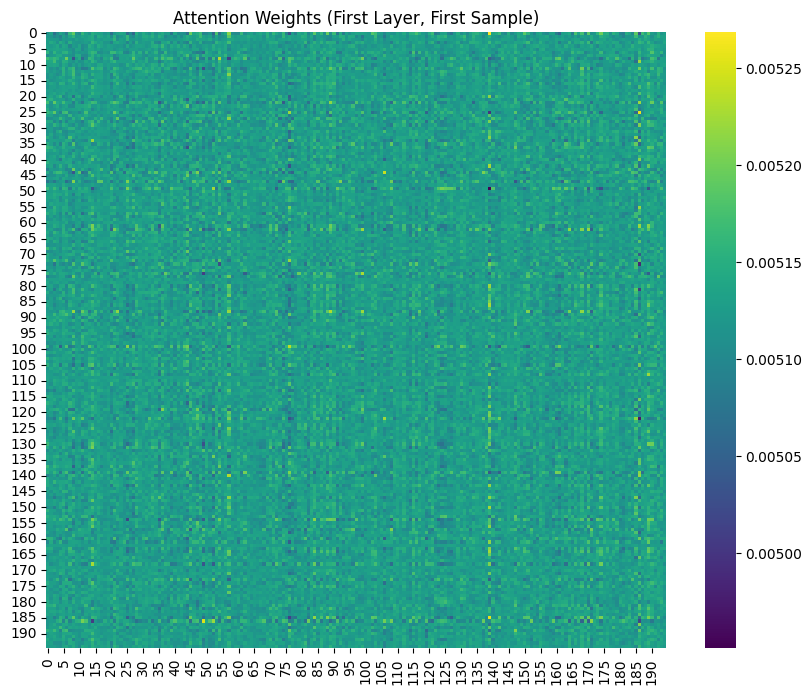

Top 20 feature interactions with 'TP53':
PDGFRB: 0.005189034156501293
HIF1A: 0.005181184038519859
PLAUR: 0.005179320462048054
KRAS: 0.005177386105060577
HOXA11: 0.005169644486159086
TFDP1: 0.005168343894183636
APAF1: 0.005167744122445583
HSP90AB1: 0.005161042790859938
IL6: 0.005159697961062193
SIAH1: 0.005158715415745974
ECT2: 0.0051576802507042885
VEGFA: 0.005154720041900873
SESN2: 0.005154220387339592
PRKN: 0.005154140759259462
SLC2A4: 0.0051531982608139515
PRKG1: 0.005150749813765287
MAPK1: 0.005149845965206623
TIGAR: 0.005149812437593937
TNFRSF10A: 0.0051496815867722034
SERPINF1: 0.00514952139928937


In [ ]:
################## works!!

import math
import typing as ty

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from torch import Tensor
import matplotlib.pyplot as plt
import seaborn as sns

class Tokenizer(nn.Module):
    category_offsets: ty.Optional[Tensor]

    def __init__(
        self,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        d_token: int,
        bias: bool,
    ) -> None:
        super().__init__()
        if categories is None:
            d_bias = d_numerical
            self.category_offsets = None
            self.category_embeddings = None
        else:
            d_bias = d_numerical + len(categories)
            category_offsets = torch.tensor([0] + categories[:-1]).cumsum(0)
            self.register_buffer('category_offsets', category_offsets)
            self.category_embeddings = nn.Embedding(sum(categories), d_token)
            nn_init.kaiming_uniform_(self.category_embeddings.weight, a=math.sqrt(5))

        self.weight = nn.Parameter(Tensor(d_numerical + 1, d_token))
        self.bias = nn.Parameter(Tensor(d_bias, d_token)) if bias else None
        nn_init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            nn_init.kaiming_uniform_(self.bias, a=math.sqrt(5))

    @property
    def n_tokens(self) -> int:
        return len(self.weight) + (
            0 if self.category_offsets is None else len(self.category_offsets)
        )

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x_some = x_num if x_cat is None else x_cat
        assert x_some is not None
        x_num = torch.cat(
            [torch.ones(len(x_some), 1, device=x_some.device)]
            + ([] if x_num is None else [x_num]),
            dim=1,
        )
        x = self.weight[None] * x_num[:, :, None]
        if x_cat is not None:
            x = torch.cat(
                [x, self.category_embeddings(x_cat + self.category_offsets[None])],
                dim=1,
            )
        if self.bias is not None:
            bias = torch.cat(
                [
                    torch.zeros(1, self.bias.shape[1], device=x.device),
                    self.bias,
                ]
            )
            x = x + bias[None]
        return x

class MultiheadAttention(nn.Module):
    def __init__(
        self, d: int, n_heads: int, dropout: float, initialization: str
    ) -> None:
        if n_heads > 1:
            assert d % n_heads == 0
        assert initialization in ['xavier', 'kaiming']

        super().__init__()
        self.W_q = nn.Linear(d, d)
        self.W_k = nn.Linear(d, d)
        self.W_v = nn.Linear(d, d)
        self.W_out = nn.Linear(d, d) if n_heads > 1 else None
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout) if dropout else None

        for m in [self.W_q, self.W_k, self.W_v]:
            if initialization == 'xavier' and (n_heads > 1 or m is not self.W_v):
                nn_init.xavier_uniform_(m.weight, gain=1 / math.sqrt(2))
            nn_init.zeros_(m.bias)
        if self.W_out is not None:
            nn_init.zeros_(self.W_out.bias)

    def _reshape(self, x: Tensor) -> Tensor:
        batch_size, n_tokens, d = x.shape
        d_head = d // self.n_heads
        return (
            x.reshape(batch_size, n_tokens, self.n_heads, d_head)
            .transpose(1, 2)
            .reshape(batch_size * self.n_heads, n_tokens, d_head)
        )

    def forward(
        self,
        x_q: Tensor,
        x_kv: Tensor,
        key_compression: ty.Optional[nn.Linear],
        value_compression: ty.Optional[nn.Linear],
    ) -> tuple[Tensor, Tensor]:
        q, k, v = self.W_q(x_q), self.W_k(x_kv), self.W_v(x_kv)
        for tensor in [q, k, v]:
            assert tensor.shape[-1] % self.n_heads == 0
        if key_compression is not None:
            assert value_compression is not None
            k = key_compression(k.transpose(1, 2)).transpose(1, 2)
            v = value_compression(v.transpose(1, 2)).transpose(1, 2)
        else:
            assert value_compression is None

        batch_size = len(q)
        d_head_key = k.shape[-1] // self.n_heads
        d_head_value = v.shape[-1] // self.n_heads
        n_q_tokens = q.shape[1]

        q = self._reshape(q)
        k = self._reshape(k)
        attention = F.softmax(q @ k.transpose(1, 2) / math.sqrt(d_head_key), dim=-1)
        if self.dropout is not None:
            attention = self.dropout(attention)
        x = attention @ self._reshape(v)
        x = (
            x.reshape(batch_size, self.n_heads, n_q_tokens, d_head_value)
            .transpose(1, 2)
            .reshape(batch_size, n_q_tokens, self.n_heads * d_head_value)
        )
        if self.W_out is not None:
            x = self.W_out(x)
        return x, attention

class Transformer(nn.Module):
    def __init__(
        self,
        *,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        token_bias: bool,
        n_layers: int,
        d_token: int,
        n_heads: int,
        d_ffn_factor: float,
        attention_dropout: float,
        ffn_dropout: float,
        residual_dropout: float,
        activation: str,
        prenormalization: bool,
        initialization: str,
        kv_compression: ty.Optional[float],
        kv_compression_sharing: ty.Optional[str],
        d_out: int,
    ) -> None:
        assert (kv_compression is None) ^ (kv_compression_sharing is not None)

        super().__init__()
        self.tokenizer = Tokenizer(d_numerical, categories, d_token, token_bias)
        n_tokens = self.tokenizer.n_tokens

        def make_kv_compression():
            assert kv_compression
            compression = nn.Linear(
                n_tokens, int(n_tokens * kv_compression), bias=False
            )
            if initialization == 'xavier':
                nn_init.xavier_uniform_(compression.weight)
            return compression

        self.shared_kv_compression = (
            make_kv_compression()
            if kv_compression and kv_compression_sharing == 'layerwise'
            else None
        )

        def make_normalization():
            return nn.LayerNorm(d_token)

        d_hidden = int(d_token * d_ffn_factor)
        self.layers = nn.ModuleList([])
        for layer_idx in range(n_layers):
            layer = nn.ModuleDict(
                {
                    'attention': MultiheadAttention(
                        d_token, n_heads, attention_dropout, initialization
                    ),
                    'linear0': nn.Linear(
                        d_token, d_hidden * (2 if activation.endswith('glu') else 1)
                    ),
                    'linear1': nn.Linear(d_hidden, d_token),
                    'norm1': make_normalization(),
                }
            )
            if not prenormalization or layer_idx:
                layer['norm0'] = make_normalization()
            if kv_compression and self.shared_kv_compression is None:
                layer['key_compression'] = make_kv_compression()
                if kv_compression_sharing == 'headwise':
                    layer['value_compression'] = make_kv_compression()
                else:
                    assert kv_compression_sharing == 'key-value'
            self.layers.append(layer)

        self.activation = nn.ReLU() if activation == 'relu' else nn.GELU()
        self.last_activation = nn.ReLU() if activation == 'relu' else nn.GELU()
        self.prenormalization = prenormalization
        self.last_normalization = make_normalization() if prenormalization else None
        self.ffn_dropout = ffn_dropout
        self.residual_dropout = residual_dropout
        self.head = nn.Linear(d_token, d_out)

    def _get_kv_compressions(self, layer):
        return (
            (self.shared_kv_compression, self.shared_kv_compression)
            if self.shared_kv_compression is not None
            else (layer['key_compression'], layer['value_compression'])
            if 'key_compression' in layer and 'value_compression' in layer
            else (layer['key_compression'], layer['key_compression'])
            if 'key_compression' in layer
            else (None, None)
        )

    def _start_residual(self, x, layer, norm_idx):
        x_residual = x
        if self.prenormalization:
            norm_key = f'norm{norm_idx}'
            if norm_key in layer:
                x_residual = layer[norm_key](x_residual)
        return x_residual

    def _end_residual(self, x, x_residual, layer, norm_idx):
        if self.residual_dropout:
            x_residual = F.dropout(x_residual, self.residual_dropout, self.training)
        x = x + x_residual
        if not self.prenormalization:
            x = layer[f'norm{norm_idx}'](x)
        return x

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x = self.tokenizer(x_num, x_cat)
        attention_weights = []

        for layer_idx, layer in enumerate(self.layers):
            is_last_layer = layer_idx + 1 == len(self.layers)
            layer = ty.cast(ty.Dict[str, nn.Module], layer)

            x_residual = self._start_residual(x, layer, 0)
            x_residual, attention = layer['attention']( # Capture attention weights
                (x_residual[:, :1] if is_last_layer else x_residual),
                x_residual,
                *self._get_kv_compressions(layer),
            )
            attention_weights.append(attention) # Append attention weights
            if is_last_layer:
                x = x[:, : x_residual.shape[1]]
            x = self._end_residual(x, x_residual, layer, 0)

            x_residual = self._start_residual(x, layer, 1)
            x_residual = layer['linear0'](x_residual)
            x_residual = self.activation(x_residual)
            if self.ffn_dropout:
                x_residual = F.dropout(x_residual, self.ffn_dropout, self.training)
            x_residual = layer['linear1'](x_residual)
            x = self._end_residual(x, x_residual, layer, 1)

        assert x.shape[1] == 1
        x = x[:, 0]
        if self.last_normalization is not None:
            x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x, attention_weights

def main(file_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    df = pd.read_excel(file_path)
    df = df.iloc[:, 2:]
    target_column = df.columns[0]
    df = df[pd.to_numeric(df[target_column], errors='coerce').notna()]
    y = df[target_column].values
    y = y.astype(np.float32)
    X = df.drop(target_column, axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train_num = X_train.select_dtypes(include=np.number).values
    X_test_num = X_test.select_dtypes(include=np.number).values
    X_train_cat = None
    X_test_cat = None

    categories = None
    if X.select_dtypes(include='category').shape[1] > 0:
        X_train_cat = X_train.select_dtypes(include='category').apply(lambda x: x.cat.codes).values
        X_test_cat = X_test.select_dtypes(include='category').apply(lambda x: x.cat.codes).values
        categories = [len(X_train[col].cat.categories) for col in X_train.select_dtypes(include='category').columns]

    X_train_num = torch.tensor(X_train_num, dtype=torch.float32).to(device) if X_train_num is not None else None
    X_test_num = torch.tensor(X_test_num, dtype=torch.float32).to(device) if X_test_num is not None else None
    X_train_cat = torch.tensor(X_train_cat, dtype=torch.int64).to(device) if X_train_cat is not None else None
    X_test_cat = torch.tensor(X_test_cat, dtype=torch.int64).to(device) if X_test_cat is not None else None
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    model = Transformer(
        d_numerical=0 if X_train_num is None else X_train_num.shape[1],
        categories=categories,
        d_out=1,
        n_layers=2,
        d_token=64,
        n_heads=4,
        d_ffn_factor=4,
        attention_dropout=0.1,
        ffn_dropout=0.1,
        residual_dropout=0.1,
        activation='relu',
        prenormalization=False,
        initialization='kaiming',
        kv_compression=None,
        kv_compression_sharing=None,
        token_bias=True,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    n_epochs = 200
    for epoch in range(n_epochs):
        model.train()
        y_pred_train, _ = model(X_train_num, X_train_cat)
        y_pred_train = y_pred_train.squeeze()
        loss = loss_fn(y_pred_train, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred_test, attention_weights = model(X_test_num, X_test_cat) # Get attention weights
            y_pred_test = y_pred_test.squeeze().cpu().numpy()
            y_test_np = y_test.cpu().numpy()
            mse = mean_squared_error(y_test_np, y_pred_test)
            print(f'Epoch {epoch + 1}, Loss: {loss.item()}, MSE: {mse}')

            if epoch == n_epochs - 1: # Visualize at the last epoch
              # Visualize attention weights of the first layer and the first sample
              attention = attention_weights[0][0].cpu().numpy() # Average over heads
              if len(attention.shape) == 2: # Check if it is a 2D matrix.
                  plt.figure(figsize=(10, 8))
                  sns.heatmap(attention, annot=False, cmap='viridis') # annot=False if there are too many tokens.
                  plt.title('Attention Weights (First Layer, First Sample)')
                  plt.show()
              else:
                  print("Attention matrix is not 2D.")

                              # Get the index of the target feature
              try:
                  target_feature_index = list(X_train.columns).index(target_feature_name)
              except ValueError:
                  print(f"Target feature '{target_feature_name}' not found in the data.")
                  return

              # Extract attention values for the target feature
              target_feature_attention = attention[target_feature_index]

              # Get top 20 interactions
              feature_names = list(X_train.columns)
              feature_attention_pairs = list(zip(feature_names, target_feature_attention))
              feature_attention_pairs.sort(key=lambda x: x[1], reverse=True)
              top_20_interactions = feature_attention_pairs[:20]

              print(f"Top 20 feature interactions with '{target_feature_name}':")
              for feature, attention_value in top_20_interactions:
                  print(f"{feature}: {attention_value}")
if __name__ == "__main__":
    file_path = '/content/Gene_data.xlsx'  # Replace with your file path
    target_feature_name = 'TP53'
    main(file_path)

# FT Transformer base code

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Load and prepare the data
def load_data(file_path):
    """Load data from Excel file and prepare it according to specifications"""
    df = pd.read_excel(file_path)

    # Drop the first two ID columns
    df = df.iloc[:, 2:]

    # Handle the target column (3rd column, now at index 0 after dropping ID columns)
    target_col = df.columns[0]

    # First, identify and drop rows with '[Not Available]' in target
    not_available_mask = df[target_col] == '[Not Available]'
    print(f"Dropping {not_available_mask.sum()} rows with '[Not Available]' in target")
    df = df[~not_available_mask]

    # Now convert target to numeric, this should work since we removed '[Not Available]'
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Drop any remaining rows where target is NaN
    na_mask = df[target_col].isna()
    if na_mask.any():
        print(f"Dropping {na_mask.sum()} rows with NaN in target after conversion")
        df = df[~na_mask]

    # Split features and target
    X = df.iloc[:, 1:].values  # Features (all columns except the target)
    y = df.iloc[:, 0].values   # Target (first column after dropping IDs)

    # Ensure features are numeric
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    return X, y

# 2. Create a custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y, feature_tokenizer=None):
        # Ensure X and y are the correct types before creating tensors
        X = X.astype(np.float32)
        y = y.astype(np.float32)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.feature_tokenizer = feature_tokenizer

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_sample = self.X[idx]

        # Apply feature tokenization if available
        if self.feature_tokenizer is not None:
            X_sample = self.feature_tokenizer(X_sample)

        return X_sample, self.y[idx]

# 3. Feature Tokenizer
class FeatureTokenizer(nn.Module):
    def __init__(self, input_dim, token_dim):
        super().__init__()
        self.tokenizer = nn.Linear(input_dim, token_dim)
        self.activation = nn.GELU()

    def forward(self, x):
        # Transform features into tokens
        return self.activation(self.tokenizer(x))

# 4. Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Self-attention with residual connection
        attn_output, _ = self.attention(x, x, x)
        x = self.layernorm1(x + self.dropout(attn_output))

        # Feed-forward network with residual connection
        ff_output = self.ff(x)
        x = self.layernorm2(x + self.dropout(ff_output))
        return x

# 5. Feature Tokenizer Transformer model
class FTTransformer(nn.Module):
    def __init__(self, input_dim, token_dim, num_layers, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.feature_tokenizer = FeatureTokenizer(input_dim, token_dim)

        # Position embedding - for tabular data, we're using a simple embedding for each feature
        self.pos_embedding = nn.Parameter(torch.randn(1, 1, token_dim))

        # Transformer encoder layers
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        # Output prediction head
        self.out = nn.Linear(token_dim, 1)

    def forward(self, x):
        # Tokenize features
        x = self.feature_tokenizer(x)

        # Add position information (reshape for transformer expected input)
        x = x.unsqueeze(1)  # [batch_size, 1, token_dim]
        x = x + self.pos_embedding

        # Apply transformer layers
        for layer in self.transformer_layers:
            x = layer(x)

        # Get prediction from the output embedding
        return self.out(x.squeeze(1))

# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_ft_transformer_model.pth')

    return train_losses, val_losses

# 7. Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.cpu().numpy().flatten())

    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f'Test MSE: {mse:.4f}')
    print(f'Test MAE: {mae:.4f}')
    print(f'Test R²: {r2:.4f}')

    # Plot predictions vs actuals
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals, predictions, alpha=0.5)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.savefig('predictions_plot.png')
    plt.close()

    return mse, mae, r2, predictions, actuals

# 8. Check for missing values and handle them
def preprocess_data(X, y):
    """Handle missing values and non-numeric data in features and target"""
    # Check for non-numeric values in features
    try:
        X = X.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in features, attempting to clean...")
        # For each column
        for col in range(X.shape[1]):
            # Try to convert to float
            try:
                X[:, col] = np.array([float(x) if x != '[Not Available]' else np.nan for x in X[:, col]])
            except (ValueError, TypeError):
                # If conversion fails, set to NaN
                print(f"Column {col} contains non-numeric values that couldn't be converted")
                X[:, col] = np.array([np.nan for _ in X[:, col]])

    # Check for missing values in features
    if np.isnan(X).any():
        print(f"Found {np.isnan(X).sum()} missing values in features")
        # Simple imputation with mean
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any():
                X[mask, col] = np.mean(X[~mask, col])

    # Check for non-numeric values in target
    try:
        y = y.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in target, attempting to clean...")
        # Try to convert each value
        y_clean = []
        valid_indices = []
        for i, val in enumerate(y):
            try:
                y_clean.append(float(val) if val != '[Not Available]' else np.nan)
                if val != '[Not Available]':
                    valid_indices.append(i)
            except (ValueError, TypeError):
                y_clean.append(np.nan)

        y = np.array(y_clean)
        # Keep only rows with valid target values
        X = X[valid_indices]
        y = y[valid_indices]

    # Check for missing values in target
    if np.isnan(y).any():
        print(f"Found {np.isnan(y).sum()} missing values in target")
        # Drop these rows
        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

    return X, y

# 9. Main function to run the entire pipeline
def main(file_path, batch_size=16, test_size=0.2, val_size=0.1,
         token_dim=64, num_layers=2, num_heads=4, ff_dim=128,
         dropout=0.1, learning_rate=0.001, num_epochs=100):

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load data
    print("Loading and preparing data...")
    X, y = load_data(file_path)
    print(f"Data loaded: {X.shape[0]} samples with {X.shape[1]} features")

    # Preprocess data
    X, y = preprocess_data(X, y)
    print(f"After preprocessing: {X.shape[0]} samples with {X.shape[1]} features")

    # Split data into train+val and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Further split train+val into train and val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size/(1-test_size), random_state=42
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Create data loaders
    train_dataset = TabularDataset(X_train, y_train)
    val_dataset = TabularDataset(X_val, y_val)
    test_dataset = TabularDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Define model
    input_dim = X_train.shape[1]  # Number of features
    model = FTTransformer(
        input_dim=input_dim,
        token_dim=token_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout=dropout
    ).to(device)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train model
    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, device
    )

    # Load best model
    model.load_state_dict(torch.load('best_ft_transformer_model.pth'))

    # Evaluate model
    print("\nEvaluating model...")
    mse, mae, r2, predictions, actuals = evaluate_model(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.close()

    return model, scaler, mse, mae, r2

# Example usage
if __name__ == "__main__":
    file_path = "/content/Gene_data.xlsx"  # Replace with your Excel file path

    model, scaler, mse, mae, r2 = main(
        file_path=file_path,
        batch_size=16,      # Smaller batch size for small dataset
        test_size=0.2,
        val_size=0.1,
        token_dim=64,       # Larger token dimension for many features (194)
        num_layers=3,       # More layers for complex relationships
        num_heads=8,        # More attention heads
        ff_dim=128,         # Feed-forward dimension
        dropout=0.2,        # Slightly higher dropout for regularization
        learning_rate=0.001,
        num_epochs=150      # More epochs for better convergence
    )

    print(f"\nFinal Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

# 10. Function to make predictions with the trained model
def predict_with_model(model, scaler, new_data, device):
    """Make predictions with the trained model on new data"""
    # Preprocess new data
    new_data = scaler.transform(new_data)
    new_data = torch.tensor(new_data, dtype=torch.float32).to(device)

    # Make predictions
    model.eval()
    with torch.no_grad():
        predictions = model(new_data)

    return predictions.cpu().numpy().flatten()

Using device: cuda
Loading and preparing data...
Dropping 9 rows with '[Not Available]' in target
Data loaded: 504 samples with 194 features
After preprocessing: 504 samples with 194 features
Train set: 352 samples
Validation set: 51 samples
Test set: 101 samples

Starting training...
Epoch 1/150, Train Loss: 1612.3620, Val Loss: 1449.2767
Epoch 2/150, Train Loss: 1511.5516, Val Loss: 1360.7074
Epoch 3/150, Train Loss: 1442.3967, Val Loss: 1264.8403
Epoch 4/150, Train Loss: 1367.9284, Val Loss: 1170.8273
Epoch 5/150, Train Loss: 1295.2294, Val Loss: 1073.2064
Epoch 6/150, Train Loss: 1223.7490, Val Loss: 977.9357
Epoch 7/150, Train Loss: 1158.2582, Val Loss: 889.7779
Epoch 8/150, Train Loss: 1102.4093, Val Loss: 811.9220
Epoch 9/150, Train Loss: 1058.0840, Val Loss: 742.9945
Epoch 10/150, Train Loss: 1021.7088, Val Loss: 691.9892
Epoch 11/150, Train Loss: 997.3740, Val Loss: 649.8678
Epoch 12/150, Train Loss: 979.8089, Val Loss: 617.3593
Epoch 13/150, Train Loss: 969.9468, Val Loss: 59

# first attempt at visualization

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Load and prepare the data
def load_data(file_path):
    """Load data from Excel file and prepare it according to specifications"""
    df = pd.read_excel(file_path)

    # Drop the first two ID columns
    df = df.iloc[:, 2:]

    # Handle the target column (3rd column, now at index 0 after dropping ID columns)
    target_col = df.columns[0]

    # First, identify and drop rows with '[Not Available]' in target
    not_available_mask = df[target_col] == '[Not Available]'
    print(f"Dropping {not_available_mask.sum()} rows with '[Not Available]' in target")
    df = df[~not_available_mask]

    # Now convert target to numeric, this should work since we removed '[Not Available]'
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Drop any remaining rows where target is NaN
    na_mask = df[target_col].isna()
    if na_mask.any():
        print(f"Dropping {na_mask.sum()} rows with NaN in target after conversion")
        df = df[~na_mask]

    # Split features and target
    X = df.iloc[:, 1:].values  # Features (all columns except the target)
    y = df.iloc[:, 0].values   # Target (first column after dropping IDs)

    # Ensure features are numeric
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    return X, y

# 2. Create a custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y, feature_tokenizer=None):
        # Ensure X and y are the correct types before creating tensors
        X = X.astype(np.float32)
        y = y.astype(np.float32)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.feature_tokenizer = feature_tokenizer

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_sample = self.X[idx]

        # Apply feature tokenization if available
        if self.feature_tokenizer is not None:
            X_sample = self.feature_tokenizer(X_sample)

        return X_sample, self.y[idx]

# 3. Feature Tokenizer
class FeatureTokenizer(nn.Module):
    def __init__(self, input_dim, token_dim):
        super().__init__()
        self.tokenizer = nn.Linear(input_dim, token_dim)
        self.activation = nn.GELU()

    def forward(self, x):
        # Transform features into tokens
        return self.activation(self.tokenizer(x))

# 4. Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        # Self-attention with residual connection
        attn_output, attn_weights = self.attention(x, x, x)
        x = self.layernorm1(x + self.dropout(attn_output))

        # Feed-forward network with residual connection
        ff_output = self.ff(x)
        x = self.layernorm2(x + self.dropout(ff_output))

        if return_attention:
            return x, attn_weights
        return x

# 5. Feature Tokenizer Transformer model
class FTTransformer(nn.Module):
    def __init__(self, input_dim, token_dim, num_layers, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.feature_tokenizer = FeatureTokenizer(input_dim, token_dim)

        # Position embedding - for tabular data, we're using a simple embedding for each feature
        self.pos_embedding = nn.Parameter(torch.randn(1, 1, token_dim))

        # Transformer encoder layers
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        # Output prediction head
        self.out = nn.Linear(token_dim, 1)

    def forward(self, x, return_attention=False):
        # Tokenize features
        x = self.feature_tokenizer(x)

        # Add position information (reshape for transformer expected input)
        x = x.unsqueeze(1)  # [batch_size, 1, token_dim]
        x = x + self.pos_embedding

        # Apply transformer layers
        attention_weights = []
        for layer in self.transformer_layers:
            if return_attention:
                x, attn_weight = layer(x, return_attention=True)
                attention_weights.append(attn_weight)
            else:
                x = layer(x)

        # Get prediction from the output embedding
        output = self.out(x.squeeze(1))

        if return_attention:
            return output, attention_weights
        return output

# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_ft_transformer_model.pth')

    return train_losses, val_losses

# 7. Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.cpu().numpy().flatten())

    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f'Test MSE: {mse:.4f}')
    print(f'Test MAE: {mae:.4f}')
    print(f'Test R²: {r2:.4f}')

    # Plot predictions vs actuals
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals, predictions, alpha=0.5)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.savefig('predictions_plot.png')
    plt.close()

    return mse, mae, r2, predictions, actuals

# 8. Check for missing values and handle them
def preprocess_data(X, y):
    """Handle missing values and non-numeric data in features and target"""
    # Check for non-numeric values in features
    try:
        X = X.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in features, attempting to clean...")
        # For each column
        for col in range(X.shape[1]):
            # Try to convert to float
            try:
                X[:, col] = np.array([float(x) if x != '[Not Available]' else np.nan for x in X[:, col]])
            except (ValueError, TypeError):
                # If conversion fails, set to NaN
                print(f"Column {col} contains non-numeric values that couldn't be converted")
                X[:, col] = np.array([np.nan for _ in X[:, col]])

    # Check for missing values in features
    if np.isnan(X).any():
        print(f"Found {np.isnan(X).sum()} missing values in features")
        # Simple imputation with mean
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any():
                X[mask, col] = np.mean(X[~mask, col])

    # Check for non-numeric values in target
    try:
        y = y.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in target, attempting to clean...")
        # Try to convert each value
        y_clean = []
        valid_indices = []
        for i, val in enumerate(y):
            try:
                y_clean.append(float(val) if val != '[Not Available]' else np.nan)
                if val != '[Not Available]':
                    valid_indices.append(i)
            except (ValueError, TypeError):
                y_clean.append(np.nan)

        y = np.array(y_clean)
        # Keep only rows with valid target values
        X = X[valid_indices]
        y = y[valid_indices]

    # Check for missing values in target
    if np.isnan(y).any():
        print(f"Found {np.isnan(y).sum()} missing values in target")
        # Drop these rows
        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

    return X, y


# Add function to visualize attention weights
def visualize_attention(model, X, feature_names=None, layer_idx=0, head_idx=0, sample_idx=0):
    """
    Visualize attention weights for a specific sample

    Args:
        model: Trained FT Transformer model
        X: Input features (should be already preprocessed and scaled)
        feature_names: List of feature names (optional)
        layer_idx: Index of transformer layer to visualize (default: 0)
        head_idx: Index of attention head to visualize (default: 0)
        sample_idx: Index of sample to visualize (default: 0)
    """
    # Get the device the model is on
    device = next(model.parameters()).device

    # Convert X to tensor and move to the same device as model
    X_tensor = torch.tensor(X[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

    # Get attention weights
    model.eval()
    with torch.no_grad():
        _, attention_weights = model(X_tensor, return_attention=True)

    # Extract attention weights for the specified layer and head
    # Move to CPU for visualization
    layer_attention = attention_weights[layer_idx][0, head_idx].cpu().numpy()

    # Create feature names if not provided
    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(layer_attention.shape[0])]
    else:
        # Truncate to match the number of tokens
        feature_names = feature_names[:layer_attention.shape[0]]

    # Create heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(layer_attention, cmap='viridis')
    plt.colorbar(label='Attention Weight')
    plt.title(f'Attention Weights (Layer {layer_idx+1}, Head {head_idx+1})')
    plt.xlabel('Token Position')
    plt.ylabel('Token Position')

    # Add text annotations
    for i in range(layer_attention.shape[0]):
        for j in range(layer_attention.shape[1]):
            plt.text(j, i, f'{layer_attention[i, j]:.2f}',
                     ha='center', va='center', color='w' if layer_attention[i, j] < 0.5 else 'black')

    plt.tight_layout()
    plt.savefig(f'attention_layer{layer_idx+1}_head{head_idx+1}.png')
    plt.close()

    return layer_attention

def visualize_layer_attention(model, X, layer_idx=0, sample_idx=0):
    """
    Visualize attention weights across all heads in a specific layer
    """
    device = next(model.parameters()).device
    X_tensor = torch.tensor(X[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        _, attention_weights = model(X_tensor, return_attention=True)

    layer_attention = attention_weights[layer_idx][0].cpu().numpy()

    num_heads = layer_attention.shape[0]

    fig, axs = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    if num_heads == 1:
        axs = [axs]

    for h in range(num_heads):
        # Corrected part: Reshape to 2D for imshow
        attention_data = layer_attention[h].reshape(1, -1)  # Reshape to 2D
        im = axs[h].imshow(attention_data, cmap='viridis')
        axs[h].set_title(f'Head {h+1}')
        axs[h].set_xlabel('Token Position')
        if h == 0:
            axs[h].set_ylabel('Token Position')

    fig.colorbar(im, ax=axs, shrink=0.8, label='Attention Weight')
    plt.suptitle(f'Attention Weights Across All Heads (Layer {layer_idx+1})')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer_idx+1}_all_heads.png')
    plt.close()

def visualize_feature_importance(model, X, scaler, feature_names=None):
    """
    Visualize feature importance based on attention weights
    """
    device = next(model.parameters()).device

    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(X.shape[1])]

    sample_idx = 0
    X_tensor = torch.tensor(X[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        _, attention_weights = model(X_tensor, return_attention=True)

    avg_attention = None
    for layer_attn in attention_weights:
        if avg_attention is None:
            avg_attention = layer_attn.mean(dim=1)
        else:
            avg_attention += layer_attn.mean(dim=1)

    avg_attention /= len(attention_weights)
    avg_attention = avg_attention.squeeze().cpu().numpy()

    # Corrected part: Handle scalar avg_attention
    feature_importance = avg_attention  # Use the scalar value directly
    feature_std = np.std(X, axis=0)
    feature_std_scaled = feature_std / np.sum(feature_std)

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Attention': feature_importance,
        'StdScaled': feature_std_scaled,
        'Combined': feature_importance * feature_std_scaled
    })

    importance_df = importance_df.sort_values('Combined', ascending=False)

    top_n = min(20, len(importance_df))
    plt.figure(figsize=(12, 6))
    plt.barh(importance_df['Feature'][:top_n][::-1], importance_df['Combined'][:top_n][::-1])
    plt.xlabel('Importance Score (Attention × Feature Variability)')
    plt.title(f'Top {top_n} Features by Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.close()

    return importance_df

def analyze_attention_patterns(model, X, feature_names=None, n_samples=10):
    """
    Analyze attention patterns across multiple samples to identify consistent feature importance.
    """
    device = next(model.parameters()).device

    n_samples = min(n_samples, X.shape[0])

    model.eval()
    sample_attentions = []

    with torch.no_grad():
        for i in range(n_samples):
            X_tensor = torch.tensor(X[i:i+1], dtype=torch.float32).to(device)
            _, attention_weights = model(X_tensor, return_attention=True)

            avg_attention = None
            for layer_attn in attention_weights:
                if avg_attention is None:
                    avg_attention = layer_attn.mean(dim=1)
                else:
                    avg_attention += layer_attn.mean(dim=1)

            avg_attention /= len(attention_weights)
            sample_attentions.append(avg_attention.squeeze().cpu().numpy())

    all_attentions = np.array(sample_attentions)  # Convert to np array

    # Calculate mean attention across samples
    mean_attention = np.mean(all_attentions, axis=0)

    # If feature names are not provided, create generic ones
    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(X.shape[1])]

    # Plot mean attention weights
    plt.figure(figsize=(12, 6))
    plt.barh(feature_names, mean_attention)
    plt.xlabel('Mean Attention Weight')
    plt.ylabel('Features')
    plt.title(f'Mean Attention Weights Across {n_samples} Samples')
    plt.tight_layout()
    plt.savefig('mean_attention_weights.png')
    plt.close()

    return mean_attention, np.var(all_attentions, axis=0)

# 9. Main function to run the entire pipeline
def main(file_path, batch_size=16, test_size=0.2, val_size=0.1,
         token_dim=64, num_layers=2, num_heads=4, ff_dim=128,
         dropout=0.1, learning_rate=0.001, num_epochs=100):

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load data
    print("Loading and preparing data...")
    X, y = load_data(file_path)
    print(f"Data loaded: {X.shape[0]} samples with {X.shape[1]} features")

    # Preprocess data
    X, y = preprocess_data(X, y)
    print(f"After preprocessing: {X.shape[0]} samples with {X.shape[1]} features")

    # Split data into train+val and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Further split train+val into train and val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size/(1-test_size), random_state=42
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Create data loaders
    train_dataset = TabularDataset(X_train, y_train)
    val_dataset = TabularDataset(X_val, y_val)
    test_dataset = TabularDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Define model
    input_dim = X_train.shape[1]  # Number of features
    model = FTTransformer(
        input_dim=input_dim,
        token_dim=token_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout=dropout
    ).to(device)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train model
    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, device
    )

    # Load best model
    model.load_state_dict(torch.load('best_ft_transformer_model.pth'))

    # Evaluate model
    print("\nEvaluating model...")
    mse, mae, r2, predictions, actuals = evaluate_model(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.close()

    # Visualizing the model
    print("\nGenerating attention visualizations...")

    # Get feature names (all columns except the first two ID columns and target column)
    try:
        df = pd.read_excel(file_path)
        feature_names = df.columns[3:].tolist()  # Skip first 3 columns (2 IDs + target)
    except:
        feature_names = None
        print("Could not extract feature names from file")

    # Visualize attention for each layer
    for layer_idx in range(num_layers):
        visualize_layer_attention(model, X_test, layer_idx=layer_idx)

    # Visualize feature importance
    importance_df = visualize_feature_importance(model, X_test, scaler, feature_names)
    print("\nTop 10 important features:")
    print(importance_df[['Feature', 'Combined']].head(10))

    # Analyze attention patterns
    mean_attn, var_attn = analyze_attention_patterns(model, X_test, n_samples=20)

    return model, scaler, mse, mae, r2, importance_df

# Example usage
if __name__ == "__main__":
    file_path = "/content/Gene_data.xlsx"  # Replace with your Excel file path

    model, scaler, mse, mae, r2, importance_df = main(
        file_path=file_path,
        batch_size=16,      # Smaller batch size for small dataset
        test_size=0.2,
        val_size=0.1,
        token_dim=64,       # Larger token dimension for many features (194)
        num_layers=3,       # More layers for complex relationships
        num_heads=8,        # More attention heads
        ff_dim=128,         # Feed-forward dimension
        dropout=0.2,        # Slightly higher dropout for regularization
        learning_rate=0.001,
        num_epochs=200       # More epochs for better convergence
    )

    print(f"\nFinal Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Top 10 important features:\n{importance_df[['Feature', 'Combined']].head(10)}") # added in print of top 10 features.

Using device: cuda
Loading and preparing data...
Dropping 9 rows with '[Not Available]' in target
Data loaded: 504 samples with 194 features
After preprocessing: 504 samples with 194 features
Train set: 352 samples
Validation set: 51 samples
Test set: 101 samples

Starting training...
Epoch 1/200, Train Loss: 1614.3832, Val Loss: 1437.0142
Epoch 2/200, Train Loss: 1504.7227, Val Loss: 1347.2395
Epoch 3/200, Train Loss: 1431.5414, Val Loss: 1254.9695
Epoch 4/200, Train Loss: 1358.4515, Val Loss: 1157.6057
Epoch 5/200, Train Loss: 1287.1228, Val Loss: 1060.3265
Epoch 6/200, Train Loss: 1217.4714, Val Loss: 965.8620
Epoch 7/200, Train Loss: 1156.0452, Val Loss: 879.4425
Epoch 8/200, Train Loss: 1101.0959, Val Loss: 803.2018
Epoch 9/200, Train Loss: 1057.6609, Val Loss: 738.4307
Epoch 10/200, Train Loss: 1021.5107, Val Loss: 689.8365
Epoch 11/200, Train Loss: 996.7343, Val Loss: 652.2378
Epoch 12/200, Train Loss: 980.3470, Val Loss: 617.8059
Epoch 13/200, Train Loss: 968.1924, Val Loss: 59

<ipython-input-55-46a30f1823dd>:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Top 10 important features:
      Feature  Combined
98      IFNA1  0.007108
106      KRAS  0.006740
103     IQCB1  0.006392
185  TP53AIP1  0.006374
140      PEG3  0.006212
9         ATR  0.006212
172    SLC2A1  0.006174
166  SERPINF1  0.006079
41     CDKN2A  0.006018
2       ABCC1  0.005949

Final Results:
MSE: 871.7617
MAE: 20.7274
R²: -0.1980
Top 10 important features:
      Feature  Combined
98      IFNA1  0.007108
106      KRAS  0.006740
103     IQCB1  0.006392
185  TP53AIP1  0.006374
140      PEG3  0.006212
9         ATR  0.006212
172    SLC2A1  0.006174
166  SERPINF1  0.006079
41     CDKN2A  0.006018
2       ABCC1  0.005949


# visualizing with permutation technique

Using device: cuda
Loading and preparing data...
Dropping 9 rows with '[Not Available]' in target
Data loaded: 504 samples with 194 features
After preprocessing: 504 samples with 194 features
Train set: 352 samples
Validation set: 51 samples
Test set: 101 samples

Starting training...
Epoch 1/150, Train Loss: 1595.5506, Val Loss: 1434.4868
Epoch 2/150, Train Loss: 1499.4990, Val Loss: 1341.8827
Epoch 3/150, Train Loss: 1426.1796, Val Loss: 1247.7888
Epoch 4/150, Train Loss: 1352.4723, Val Loss: 1150.5380
Epoch 5/150, Train Loss: 1280.7218, Val Loss: 1052.1649
Epoch 6/150, Train Loss: 1210.1455, Val Loss: 960.9477
Epoch 7/150, Train Loss: 1150.4646, Val Loss: 872.0503
Epoch 8/150, Train Loss: 1093.5802, Val Loss: 799.8459
Epoch 9/150, Train Loss: 1050.9649, Val Loss: 736.0761
Epoch 10/150, Train Loss: 1018.2291, Val Loss: 684.7615
Epoch 11/150, Train Loss: 993.5274, Val Loss: 644.8814
Epoch 12/150, Train Loss: 977.0856, Val Loss: 613.7028
Epoch 13/150, Train Loss: 966.9859, Val Loss: 59

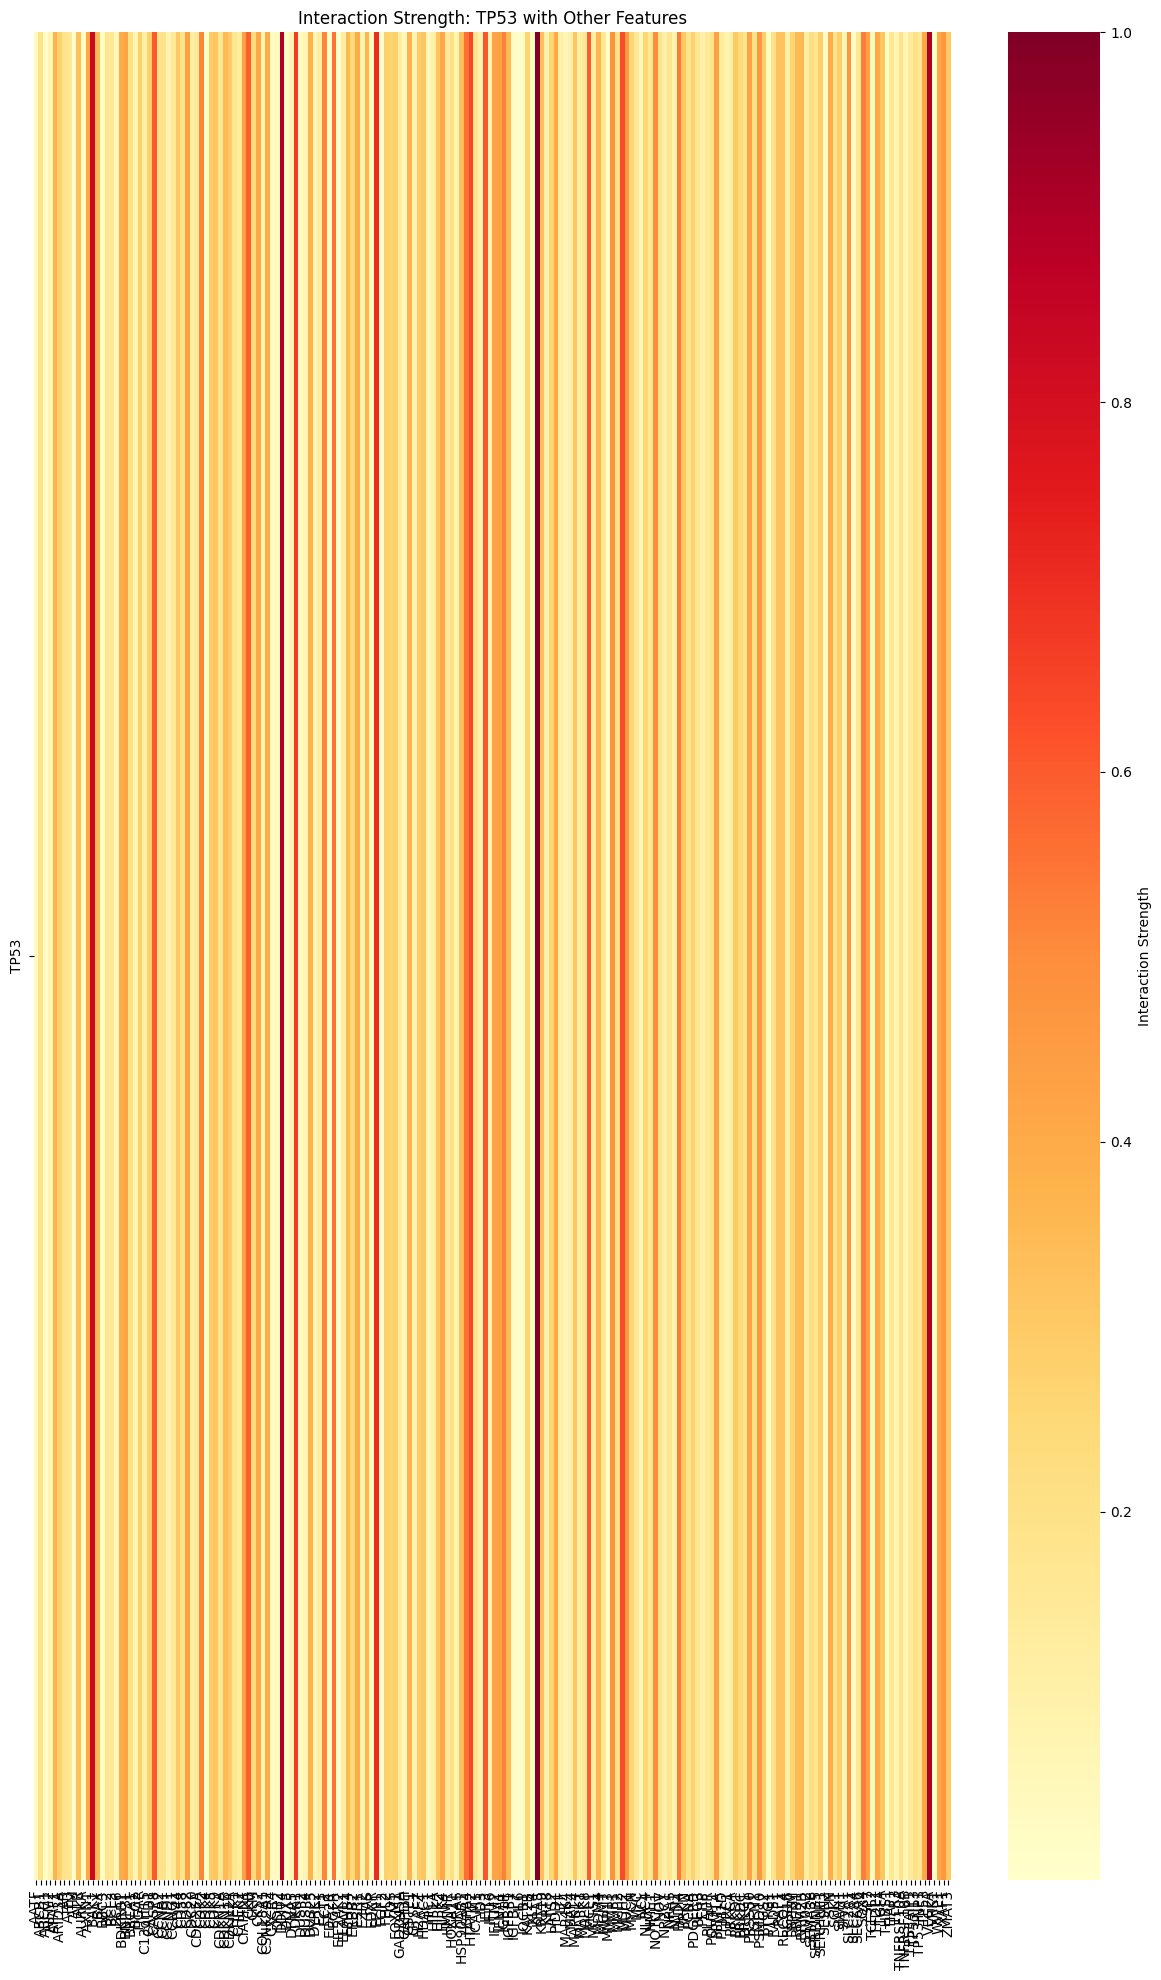

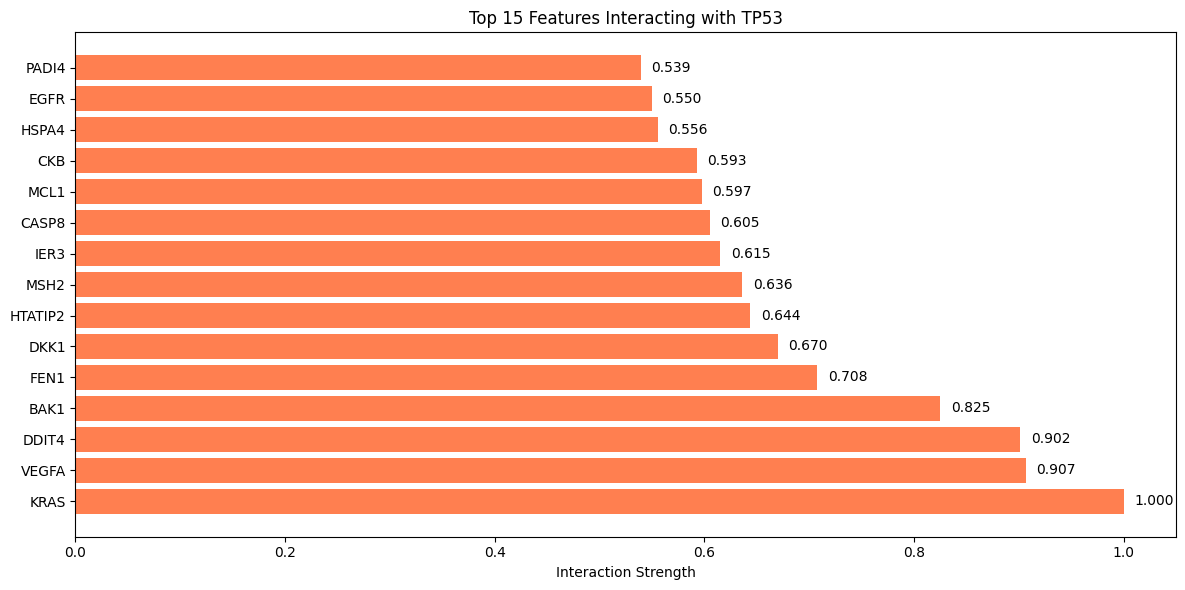

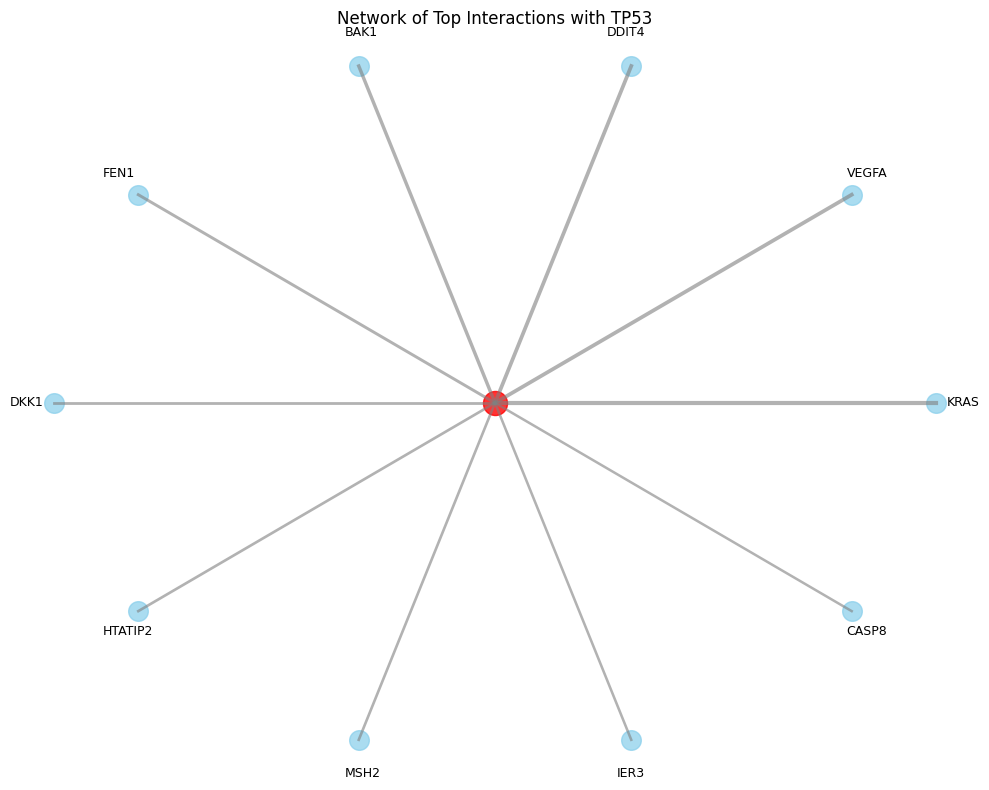


Final Results:
MSE: 845.0053
MAE: 19.2887
R²: -0.1612


In [ ]:
################################### visualizing with permutation technique !!!!!!!!!!works
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load and prepare the data
def load_data(file_path):
    """Load data from Excel file and prepare it according to specifications"""
    df = pd.read_excel(file_path)

    # Drop the first two ID columns
    df = df.iloc[:, 2:]

    # Handle the target column (3rd column, now at index 0 after dropping ID columns)
    target_col = df.columns[0]

    # First, identify and drop rows with '[Not Available]' in target
    not_available_mask = df[target_col] == '[Not Available]'
    print(f"Dropping {not_available_mask.sum()} rows with '[Not Available]' in target")
    df = df[~not_available_mask]

    # Now convert target to numeric, this should work since we removed '[Not Available]'
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Drop any remaining rows where target is NaN
    na_mask = df[target_col].isna()
    if na_mask.any():
        print(f"Dropping {na_mask.sum()} rows with NaN in target after conversion")
        df = df[~na_mask]

    # Split features and target
    X = df.iloc[:, 1:].values  # Features (all columns except the target)
    y = df.iloc[:, 0].values   # Target (first column after dropping IDs)

    # Ensure features are numeric
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    return X, y

# 2. Create a custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y, feature_tokenizer=None):
        # Ensure X and y are the correct types before creating tensors
        X = X.astype(np.float32)
        y = y.astype(np.float32)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.feature_tokenizer = feature_tokenizer

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_sample = self.X[idx]

        # Apply feature tokenization if available
        if self.feature_tokenizer is not None:
            X_sample = self.feature_tokenizer(X_sample)

        return X_sample, self.y[idx]

# 3. Feature Tokenizer
class FeatureTokenizer(nn.Module):
    def __init__(self, input_dim, token_dim):
        super().__init__()
        self.tokenizer = nn.Linear(input_dim, token_dim)
        self.activation = nn.GELU()

    def forward(self, x):
        # Transform features into tokens
        return self.activation(self.tokenizer(x))

# 4. Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        # Self-attention with residual connection
        attn_output, attn_weights = self.attention(x, x, x, need_weights=return_attention)
        x = self.layernorm1(x + self.dropout(attn_output))

        # Feed-forward network with residual connection
        ff_output = self.ff(x)
        x = self.layernorm2(x + self.dropout(ff_output))

        if return_attention:
            return x, attn_weights
        return x

# 5. Feature Tokenizer Transformer model
class FTTransformer(nn.Module):
    def __init__(self, input_dim, token_dim, num_layers, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.feature_tokenizer = FeatureTokenizer(input_dim, token_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 1, token_dim))
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.out = nn.Linear(token_dim, 1)
        self.num_heads = num_heads

    def forward(self, x, return_attention=False):
        # Tokenize features
        x = self.feature_tokenizer(x)

        # Add position information
        x = x.unsqueeze(1)  # [batch_size, 1, token_dim]
        x = x + self.pos_embedding

        attention_weights = []

        # Apply transformer layers
        for layer in self.transformer_layers:
            if return_attention:
                x, attn_weight = layer(x, return_attention=True)
                attention_weights.append(attn_weight)
            else:
                x = layer(x)

        # Get prediction from the output embedding
        output = self.out(x.squeeze(1))

        if return_attention:
            return output, attention_weights
        return output



####################################visualization code
#Function to extract attention weights for specific features

def extract_feature_interactions(model, data, feature_index, feature_names=None):
    """
    Extract interactions between a specific feature and all other features
    using a perturbation-based approach.

    Args:
        model: Trained FT Transformer model
        data: Input data (scaled)
        feature_index: Index of the feature to focus on
        feature_names: List of feature names

    Returns:
        Interaction matrix and feature names
    """
    # Ensure model is in evaluation mode
    model.eval()
    device = next(model.parameters()).device

    # Convert to tensor if needed
    if not isinstance(data, torch.Tensor):
        data = torch.tensor(data, dtype=torch.float32)

    # Move to appropriate device
    data = data.to(device)
    n_samples, n_features = data.shape

    # Create feature names if not provided
    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(n_features)]

    # Selected feature name
    feature_name = feature_names[feature_index]

    # Matrix to store interactions
    interaction_strength = np.zeros((n_features, n_features))

    # Get baseline predictions
    with torch.no_grad():
        baseline_preds = model(data).cpu().numpy()

    # For each pair of features (focus feature + one other)
    for other_idx in range(n_features):
        if other_idx == feature_index:
            # Self-interaction is set to 1.0
            interaction_strength[feature_index, other_idx] = 1.0
            continue

        # Create perturbed data - change both features simultaneously
        perturbed_data = data.clone()

        # Calculate mean and std for the two features
        feature_mean = data[:, feature_index].mean().item()
        feature_std = data[:, feature_index].std().item()
        other_mean = data[:, other_idx].mean().item()
        other_std = data[:, other_idx].std().item()

        # Create 5 perturbation levels
        perturbation_levels = np.linspace(-2, 2, 5)  # -2σ to +2σ
        results = []

        for level in perturbation_levels:
            # Perturb both features by same sigma level
            perturbed_data[:, feature_index] = torch.tensor(
                feature_mean + level * feature_std, device=device
            ).expand(n_samples)
            perturbed_data[:, other_idx] = torch.tensor(
                other_mean + level * other_std, device=device
            ).expand(n_samples)

            # Get new predictions
            with torch.no_grad():
                perturbed_preds = model(perturbed_data).cpu().numpy()

            # Store mean change in prediction
            results.append((level, (perturbed_preds - baseline_preds).mean()))

        # Extract x and y values
        x_vals, y_vals = zip(*results)

        # Fit linear regression to measure interaction strength
        reg = LinearRegression().fit(np.array(x_vals).reshape(-1, 1), y_vals)
        interaction_strength[feature_index, other_idx] = abs(reg.coef_[0])

    # Normalize interaction strengths
    if interaction_strength[feature_index].sum() > 0:
        interaction_strength[feature_index] /= interaction_strength[feature_index].max()

    return interaction_strength[feature_index], feature_names

def visualize_feature_interactions(model, data, feature_index, feature_names=None, top_n=15):
    """
    Visualize interactions between a specific feature and other features.

    Args:
        model: Trained FT Transformer model
        data: Input data (scaled)
        feature_index: Index of the feature to analyze
        feature_names: List of feature names
        top_n: Number of top interactions to display
    """
    # Extract feature interactions
    interactions, feature_names = extract_feature_interactions(
        model, data, feature_index, feature_names
    )

    # Get feature name
    feature_name = feature_names[feature_index]

    # Create two visualizations

    # 1. Heatmap-style visualization
    plt.figure(figsize=(12, 0.5 + len(feature_names)/10))

    # Reshape for heatmap
    interactions_matrix = interactions.reshape(1, -1)

    # Create heatmap
    ax = sns.heatmap(
        interactions_matrix,
        cmap="YlOrRd",
        xticklabels=feature_names,
        yticklabels=[feature_name],
        cbar_kws={'label': 'Interaction Strength'}
    )

    plt.title(f"Interaction Strength: {feature_name} with Other Features")
    plt.tight_layout()
    plt.savefig(f'feature{feature_index+1}_interactions_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Bar chart with top interactions
    # Sort interactions
    other_indices = np.argsort(interactions)[::-1]

    # Remove self-interaction and take top N
    other_indices = [idx for idx in other_indices if idx != feature_index][:top_n]

    # Get names and interaction values
    other_names = [feature_names[idx] for idx in other_indices]
    interaction_values = [interactions[idx] for idx in other_indices]

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(interaction_values)), interaction_values, color='coral')
    plt.yticks(range(len(interaction_values)), other_names)
    plt.xlabel('Interaction Strength')
    plt.title(f'Top {top_n} Features Interacting with {feature_name}')

    # Add values on bars
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{interaction_values[i]:.3f}', va='center')

    plt.tight_layout()
    plt.savefig(f'feature{feature_index+1}_top_interactions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Network-like visualization for strongest interactions
    plt.figure(figsize=(10, 8))

    # Take top interactions only
    top_indices = other_indices[:min(10, len(other_indices))]
    top_names = [feature_names[idx] for idx in top_indices]
    top_values = [interactions[idx] for idx in top_indices]

    # Create node positions in a circular layout
    angles = np.linspace(0, 2*np.pi, len(top_indices)+1)[:-1]
    radius = 5
    node_positions = {
        'center': (0, 0),  # Center position for the feature of interest
        **{idx: (radius * np.cos(angle), radius * np.sin(angle))
           for idx, angle in zip(top_indices, angles)}
    }

    # Draw edges (connections)
    max_width = 3
    for i, (idx, val) in enumerate(zip(top_indices, top_values)):
        x1, y1 = node_positions['center']
        x2, y2 = node_positions[idx]
        plt.plot([x1, x2], [y1, y2], 'gray', alpha=0.6,
                 linewidth=max_width * val)

    # Draw nodes
    plt.scatter(0, 0, s=300, c='red', alpha=0.8, label=feature_name)
    for idx, name in zip(top_indices, top_names):
        x, y = node_positions[idx]
        plt.scatter(x, y, s=200, c='skyblue', alpha=0.7)
        plt.text(x*1.1, y*1.1, name, fontsize=9,
                ha='center' if abs(x) < 0.1 else ('left' if x < 0 else 'right'),
                va='center')

    plt.title(f"Network of Top Interactions with {feature_name}")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'feature{feature_index+1}_interaction_network.png', dpi=300, bbox_inches='tight')
    plt.show()

    return interactions

def demonstrate_feature_interactions(model, X_test, feature_index, feature_names=None):
    """
    Demonstrate feature interaction visualization for a sample set of data.

    Args:
        model: Trained FT Transformer model
        X_test: Test data (numpy array or tensor)
        feature_index: Index of the feature to focus on
        feature_names: List of feature names
    """
    # Use first 100 samples for better statistical analysis (or all if fewer)
    sample_size = min(100, len(X_test))
    sample_data = X_test[:sample_size]

    print(f"\nAnalyzing interactions for feature {feature_index+1}...")
    interactions = visualize_feature_interactions(
        model=model,
        data=sample_data,
        feature_index=feature_index,
        feature_names=feature_names,
        top_n=15  # Show top 15 interacting features
    )

    return interactions

# Add this function to your main() to call the new visualization:
def visualize_interactions_in_main(model, X_test, feature_index, feature_names=None):
    """Add this to your main() function"""
    # After evaluating the model, visualize feature interactions
    print("\nVisualizing feature interactions...")
    interactions = demonstrate_feature_interactions(
        model=model,
        X_test=X_test,  # Use scaled test data
        feature_index=feature_index,  # Feature to analyze
        feature_names=feature_names
    )
    return interactions
######################################################
# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_ft_transformer_model.pth')

    return train_losses, val_losses

# 7. Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.cpu().numpy().flatten())

    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f'Test MSE: {mse:.4f}')
    print(f'Test MAE: {mae:.4f}')
    print(f'Test R²: {r2:.4f}')

    # Plot predictions vs actuals
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals, predictions, alpha=0.5)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.savefig('predictions_plot.png')
    plt.close()

    return mse, mae, r2, predictions, actuals

# 8. Check for missing values and handle them
def preprocess_data(X, y):
    """Handle missing values and non-numeric data in features and target"""
    # Check for non-numeric values in features
    try:
        X = X.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in features, attempting to clean...")
        # For each column
        for col in range(X.shape[1]):
            # Try to convert to float
            try:
                X[:, col] = np.array([float(x) if x != '[Not Available]' else np.nan for x in X[:, col]])
            except (ValueError, TypeError):
                # If conversion fails, set to NaN
                print(f"Column {col} contains non-numeric values that couldn't be converted")
                X[:, col] = np.array([np.nan for _ in X[:, col]])

    # Check for missing values in features
    if np.isnan(X).any():
        print(f"Found {np.isnan(X).sum()} missing values in features")
        # Simple imputation with mean
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any():
                X[mask, col] = np.mean(X[~mask, col])

    # Check for non-numeric values in target
    try:
        y = y.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in target, attempting to clean...")
        # Try to convert each value
        y_clean = []
        valid_indices = []
        for i, val in enumerate(y):
            try:
                y_clean.append(float(val) if val != '[Not Available]' else np.nan)
                if val != '[Not Available]':
                    valid_indices.append(i)
            except (ValueError, TypeError):
                y_clean.append(np.nan)

        y = np.array(y_clean)
        # Keep only rows with valid target values
        X = X[valid_indices]
        y = y[valid_indices]

    # Check for missing values in target
    if np.isnan(y).any():
        print(f"Found {np.isnan(y).sum()} missing values in target")
        # Drop these rows
        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

    return X, y

# 9. Main function to run the entire pipeline
def main(file_path, batch_size=16, test_size=0.2, val_size=0.1,
         token_dim=64, num_layers=2, num_heads=4, ff_dim=128,
         dropout=0.1, learning_rate=0.001, num_epochs=100):

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load data
    print("Loading and preparing data...")
    X, y = load_data(file_path)
    print(f"Data loaded: {X.shape[0]} samples with {X.shape[1]} features")

    # Preprocess data
    X, y = preprocess_data(X, y)
    print(f"After preprocessing: {X.shape[0]} samples with {X.shape[1]} features")

    # Split data into train+val and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Further split train+val into train and val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size/(1-test_size), random_state=42
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Create data loaders
    train_dataset = TabularDataset(X_train, y_train)
    val_dataset = TabularDataset(X_val, y_val)
    test_dataset = TabularDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Define model
    input_dim = X_train.shape[1]  # Number of features
    model = FTTransformer(
        input_dim=input_dim,
        token_dim=token_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout=dropout
    ).to(device)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train model
    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, device
    )

    # Load best model
    model.load_state_dict(torch.load('best_ft_transformer_model.pth'))

    # Evaluate model
    print("\nEvaluating model...")
    mse, mae, r2, predictions, actuals = evaluate_model(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.close()

    # After evaluating the model, visualize feature interactions
    # Get feature names - assuming they're in your original dataframe
    df = pd.read_excel(file_path)
    feature_names = df.iloc[:, 3:].columns.tolist()  # Skip ID columns and target

    # Select a feature to focus on (change this to the feature you're interested in)
    feature_index = df.columns.get_loc('TP53') - 3

    # Visualize interactions
    print("\nVisualizing feature interactions...")
    interactions = visualize_interactions_in_main(
        model=model,
        X_test=X_test,  # Use scaled test data
        feature_index=feature_index,
        feature_names=feature_names
    )

    return model, scaler, mse, mae, r2

# Example usage
if __name__ == "__main__":
    file_path = "/content/Gene_data.xlsx"  # Replace with your Excel file path

    model, scaler, mse, mae, r2 = main(
        file_path=file_path,
        batch_size=16,      # Smaller batch size for small dataset
        test_size=0.2,
        val_size=0.1,
        token_dim=64,       # Larger token dimension for many features (194)
        num_layers=3,       # More layers for complex relationships
        num_heads=8,        # More attention heads
        ff_dim=128,         # Feed-forward dimension
        dropout=0.2,        # Slightly higher dropout for regularization
        learning_rate=0.001,
        num_epochs=150      # More epochs for better convergence
    )

    print(f"\nFinal Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

# 10. Function to make predictions with the trained model
def predict_with_model(model, scaler, new_data, device):
    """Make predictions with the trained model on new data"""
    # Preprocess new data
    new_data = scaler.transform(new_data)
    new_data = torch.tensor(new_data, dtype=torch.float32).to(device)

    # Make predictions
    model.eval()
    with torch.no_grad():
        predictions = model(new_data)

    return predictions.cpu().numpy().flatten()

# visualize that attention scores as a heatmap

In [ ]:
########################################### visualize that attention scores as a heatmap
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Load and prepare the data
def load_data(file_path):
    """Load data from Excel file and prepare it according to specifications"""
    df = pd.read_excel(file_path)

    # Drop the first two ID columns
    df = df.iloc[:, 2:]

    # Handle the target column (3rd column, now at index 0 after dropping ID columns)
    target_col = df.columns[0]

    # First, identify and drop rows with '[Not Available]' in target
    not_available_mask = df[target_col] == '[Not Available]'
    print(f"Dropping {not_available_mask.sum()} rows with '[Not Available]' in target")
    df = df[~not_available_mask]

    # Now convert target to numeric, this should work since we removed '[Not Available]'
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Drop any remaining rows where target is NaN
    na_mask = df[target_col].isna()
    if na_mask.any():
        print(f"Dropping {na_mask.sum()} rows with NaN in target after conversion")
        df = df[~na_mask]

    # Split features and target
    X = df.iloc[:, 1:].values  # Features (all columns except the target)
    y = df.iloc[:, 0].values   # Target (first column after dropping IDs)

    # Ensure features are numeric
    X = X.astype(np.float32)
    y = y.astype(np.float32)

    return X, y

# 2. Create a custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y, feature_tokenizer=None):
        # Ensure X and y are the correct types before creating tensors
        X = X.astype(np.float32)
        y = y.astype(np.float32)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.feature_tokenizer = feature_tokenizer

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_sample = self.X[idx]

        # Apply feature tokenization if available
        if self.feature_tokenizer is not None:
            X_sample = self.feature_tokenizer(X_sample)

        return X_sample, self.y[idx]

# 3. Feature Tokenizer
class FeatureTokenizer(nn.Module):
    def __init__(self, input_dim, token_dim):
        super().__init__()
        self.tokenizer = nn.Linear(input_dim, token_dim)
        self.activation = nn.GELU()

    def forward(self, x):
        # Transform features into tokens
        return self.activation(self.tokenizer(x))

# 4. Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        # Self-attention with residual connection
        attn_output, attn_weights = self.attention(x, x, x)
        x = self.layernorm1(x + self.dropout(attn_output))

        # Feed-forward network with residual connection
        ff_output = self.ff(x)
        x = self.layernorm2(x + self.dropout(ff_output))

        if return_attention:
            return x, attn_weights
        return x

# 5. Feature Tokenizer Transformer model
class FTTransformer(nn.Module):
    def __init__(self, input_dim, token_dim, num_layers, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.feature_tokenizer = FeatureTokenizer(input_dim, token_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 1, token_dim))
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.out = nn.Linear(token_dim, 1)

    def forward(self, x, return_attention=False):
        # Tokenize features
        x = self.feature_tokenizer(x)

        # Add position information
        x = x.unsqueeze(1)  # [batch_size, 1, token_dim]
        x = x + self.pos_embedding

        attention_weights = []

        # Apply transformer layers
        for layer in self.transformer_layers:
            if return_attention:
                x, attn_weight = layer(x, return_attention=True)
                attention_weights.append(attn_weight)
            else:
                x = layer(x)

        # Get prediction
        output = self.out(x.squeeze(1))

        if return_attention:
            return output, attention_weights
        return output



# 5.5 visualize
def visualize_attention(model, data_loader, device, layer_idx=0, head_idx=0, feature_names=None):
    """
    Visualize attention scores for a specific layer and head

    Args:
        model: Trained FTTransformer model
        data_loader: DataLoader containing samples to visualize
        device: Device to run the model on
        layer_idx: Index of the transformer layer to visualize (default: 0)
        head_idx: Index of the attention head to visualize (default: 0)
        feature_names: List of feature names for axis labels (optional)
    """
    model.eval()

    # Get a batch of data
    X_batch, _ = next(iter(data_loader))
    X_batch = X_batch.to(device)

    # Get attention weights
    with torch.no_grad():
        _, attention_weights = model(X_batch, return_attention=True)

    # Extract attention weights for the specified layer and head
    # Shape: [batch_size, num_heads, seq_len, seq_len]
    layer_attention = attention_weights[layer_idx]

    # Average across batch samples or pick a specific sample
    sample_idx = 0  # You can choose any sample in the batch
    attn_map = layer_attention[sample_idx, head_idx].cpu().numpy()

    # Create heatmap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(attn_map, cmap='viridis')
    plt.colorbar(im, label='Attention Weight')

    # Add labels if feature names are provided
    if feature_names is not None:
        plt.xticks(np.arange(len(feature_names)), feature_names, rotation=90)
        plt.yticks(np.arange(len(feature_names)), feature_names)

    plt.title(f'Attention Weights - Layer {layer_idx+1}, Head {head_idx+1}')
    plt.tight_layout()
    plt.savefig(f'attention_heatmap_layer{layer_idx+1}_head{head_idx+1}.png')
    plt.show()

    return attn_map
# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_ft_transformer_model.pth')

    return train_losses, val_losses

# 7. Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(y_batch.cpu().numpy().flatten())

    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f'Test MSE: {mse:.4f}')
    print(f'Test MAE: {mae:.4f}')
    print(f'Test R²: {r2:.4f}')

    # Plot predictions vs actuals
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals, predictions, alpha=0.5)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.savefig('predictions_plot.png')
    plt.close()

    return mse, mae, r2, predictions, actuals

# 8. Check for missing values and handle them
def preprocess_data(X, y):
    """Handle missing values and non-numeric data in features and target"""
    # Check for non-numeric values in features
    try:
        X = X.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in features, attempting to clean...")
        # For each column
        for col in range(X.shape[1]):
            # Try to convert to float
            try:
                X[:, col] = np.array([float(x) if x != '[Not Available]' else np.nan for x in X[:, col]])
            except (ValueError, TypeError):
                # If conversion fails, set to NaN
                print(f"Column {col} contains non-numeric values that couldn't be converted")
                X[:, col] = np.array([np.nan for _ in X[:, col]])

    # Check for missing values in features
    if np.isnan(X).any():
        print(f"Found {np.isnan(X).sum()} missing values in features")
        # Simple imputation with mean
        for col in range(X.shape[1]):
            mask = np.isnan(X[:, col])
            if mask.any():
                X[mask, col] = np.mean(X[~mask, col])

    # Check for non-numeric values in target
    try:
        y = y.astype(np.float32)
    except (ValueError, TypeError):
        print("Found non-numeric values in target, attempting to clean...")
        # Try to convert each value
        y_clean = []
        valid_indices = []
        for i, val in enumerate(y):
            try:
                y_clean.append(float(val) if val != '[Not Available]' else np.nan)
                if val != '[Not Available]':
                    valid_indices.append(i)
            except (ValueError, TypeError):
                y_clean.append(np.nan)

        y = np.array(y_clean)
        # Keep only rows with valid target values
        X = X[valid_indices]
        y = y[valid_indices]

    # Check for missing values in target
    if np.isnan(y).any():
        print(f"Found {np.isnan(y).sum()} missing values in target")
        # Drop these rows
        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

    return X, y

# 9. Main function to run the entire pipeline
def main(file_path, batch_size=16, test_size=0.2, val_size=0.1,
         token_dim=64, num_layers=2, num_heads=4, ff_dim=128,
         dropout=0.1, learning_rate=0.001, num_epochs=100):

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load data
    print("Loading and preparing data...")
    X, y = load_data(file_path)
    print(f"Data loaded: {X.shape[0]} samples with {X.shape[1]} features")

    # Preprocess data
    X, y = preprocess_data(X, y)
    print(f"After preprocessing: {X.shape[0]} samples with {X.shape[1]} features")

    # Split data into train+val and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Further split train+val into train and val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size/(1-test_size), random_state=42
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Create data loaders
    train_dataset = TabularDataset(X_train, y_train)
    val_dataset = TabularDataset(X_val, y_val)
    test_dataset = TabularDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Define model
    input_dim = X_train.shape[1]  # Number of features
    model = FTTransformer(
        input_dim=input_dim,
        token_dim=token_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        ff_dim=ff_dim,
        dropout=dropout
    ).to(device)

    # Define loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train model
    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, num_epochs, device
    )

    # Load best model
    model.load_state_dict(torch.load('best_ft_transformer_model.pth'))

    # Evaluate model
    print("\nEvaluating model...")
    mse, mae, r2, predictions, actuals = evaluate_model(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('training_curves.png')
    plt.close()

    return model, scaler, mse, mae, r2

# Example usage
if __name__ == "__main__":
    file_path = "/content/Gene_data.xlsx"  # Replace with your Excel file path

    model, scaler, mse, mae, r2 = main(
        file_path=file_path,
        batch_size=16,      # Smaller batch size for small dataset
        test_size=0.2,
        val_size=0.1,
        token_dim=64,       # Larger token dimension for many features (194)
        num_layers=3,       # More layers for complex relationships
        num_heads=8,        # More attention heads
        ff_dim=128,         # Feed-forward dimension
        dropout=0.2,        # Slightly higher dropout for regularization
        learning_rate=0.001,
        num_epochs=150      # More epochs for better convergence
    )

    print(f"\nFinal Results:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

# 10. Function to make predictions with the trained model
def predict_with_model(model, scaler, new_data, device):
    """Make predictions with the trained model on new data"""
    # Preprocess new data
    new_data = scaler.transform(new_data)
    new_data = torch.tensor(new_data, dtype=torch.float32).to(device)

    # Make predictions
    model.eval()
    with torch.no_grad():
        predictions = model(new_data)

    return predictions.cpu().numpy().flatten()